# CartPoleGame example

Create the env, step it by hand, look at the trajectory.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path
from typing import List, Tuple

# Walk up to the repo root so `core` and `games` import regardless of cwd
here = Path.cwd().resolve()
repo_root = next(p for p in [here, *here.parents] if (p / "core" / "game.py").exists())
sys.path.insert(0, str(repo_root))

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import animation
from IPython.display import HTML

from games.cartpole.game import CartPoleGame, CartPoleState, LEFT, RIGHT

game = CartPoleGame(seed=0, render_mode="rgb_array")
game.state

CartPoleState(x=+0.0137, x_dot=-0.0230, theta=-0.0459, theta_dot=-0.0483)

## Step it by hand

A fixed action sequence — no policy. Alternating pushes cancel each other out instead of correcting the initial lean, so the pole keeps tipping the way it started and the episode ends about halfway through the sequence.

In [3]:
actions = [RIGHT, LEFT] * 20

game.reset(seed=0)
states = [game.state]
frames = [game.render()]
for action in actions:
    state, reward, done, _ = game.step(action)
    states.append(state)
    frames.append(game.render())
    if done:
        break

print(f"{len(states) - 1} steps, score={game.total_score}, done={game.done}")

/home/oliver-hayman/anaconda3/envs/NFL2026/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


20 steps, score=20.0, done=True


## The trajectory

In [4]:
print(
    f"{'t':>3}  {'action':>6}  {'x':>8}  {'x_dot':>8}  {'theta':>8}  {'theta_dot':>9}"
)
for t, state in enumerate(states):
    action = f"{actions[t - 1]:>6}" if t else "     -"
    print(
        f"{t:>3}  {action}  {state.x:>+8.4f}  {state.x_dot:>+8.4f}  "
        f"{state.theta:>+8.4f}  {state.theta_dot:>+9.4f}"
    )

  t  action         x     x_dot     theta  theta_dot
  0       -   +0.0137   -0.0230   -0.0459    -0.0483
  1       1   +0.0132   +0.1727   -0.0469    -0.3552
  2       0   +0.0167   -0.0217   -0.0540    -0.0776
  3       1   +0.0163   +0.1742   -0.0555    -0.3868
  4       0   +0.0197   -0.0201   -0.0633    -0.1121
  5       1   +0.0193   +0.1758   -0.0655    -0.4241
  6       0   +0.0229   -0.0183   -0.0740    -0.1528
  7       1   +0.0225   +0.1778   -0.0770    -0.4678
  8       0   +0.0260   -0.0162   -0.0864    -0.2004
  9       1   +0.0257   +0.1801   -0.0904    -0.5190
 10       0   +0.0293   -0.0137   -0.1008    -0.2562
 11       1   +0.0290   +0.1828   -0.1059    -0.5789
 12       0   +0.0327   -0.0107   -0.1175    -0.3213
 13       1   +0.0325   +0.1858   -0.1239    -0.6486
 14       0   +0.0362   -0.0074   -0.1369    -0.3974
 15       1   +0.0361   +0.1894   -0.1448    -0.7299
 16       0   +0.0398   -0.0034   -0.1594    -0.4861
 17       1   +0.0398   +0.1935   -0.1692    -

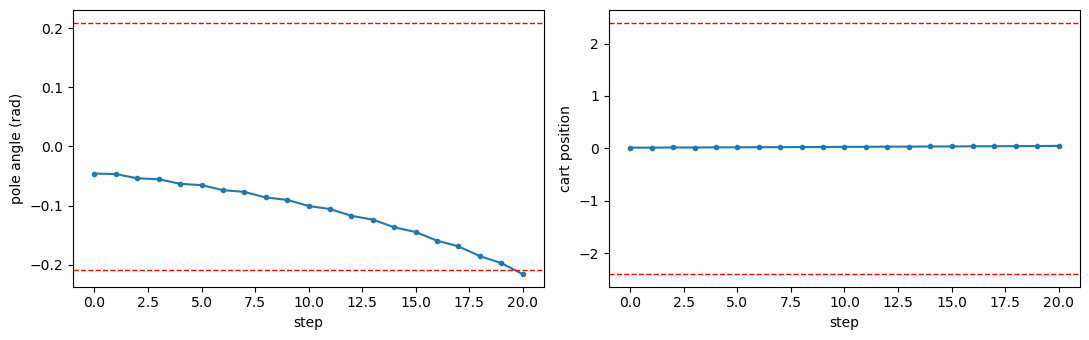

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
series = [
    ([s.theta for s in states], "pole angle (rad)", 0.2095),
    ([s.x for s in states], "cart position", 2.4),
]
for ax, (values, label, limit) in zip(axes, series):
    ax.plot(values, marker=".")
    ax.axhline(limit, ls="--", c="r", lw=1)
    ax.axhline(-limit, ls="--", c="r", lw=1)
    ax.set_xlabel("step")
    ax.set_ylabel(label)
plt.tight_layout()
plt.show()

In [6]:
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.axis("off")
image = ax.imshow(frames[0])
plt.close(fig)


def draw(i: int) -> Tuple[plt.Artist, ...]:
    image.set_data(frames[i])
    return (image,)


anim = animation.FuncAnimation(
    fig, draw, frames=len(frames), interval=1000 // 30, blit=True
)
HTML(anim.to_jshtml())